In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ray
from  tqdm import tqdm

from starforge.blackholes.parameters_recover.parameters_recovery import (
    ParametersRecoveryRemote
)

from starforge.blackholes.accretionrate.blackholesaccretionrate import (
    ParameterAccretionRate
)

from starforge.blackholes.parameters_recover.utils import (
    gaussian_sum_from_p,
    add_noise_to_data
)

from starforge.blackholes.parameters_recover.schemes import (
    GridParameters
)

In [3]:
# ============================================================
# INITIALIZE RAY
# ============================================================

if not ray.is_initialized():
    ray.init(ignore_reinit_error=True)

2026-05-18 14:22:09,411	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [4]:
# ============================================================
# GRID
# ============================================================

mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps * 100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [5]:
# ============================================================
# BENCHMARK INITIAL CONDITION
# ============================================================

benchmark_params = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])

initial_condition = gaussian_sum_from_p(
    benchmark_params,
    ln_mbh_grid,
    n_gauss=3
)

In [6]:
# ============================================================
# PHYSICAL MODEL PARAMETERS
# ============================================================

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

In [7]:
# ============================================================
# FORWARD SOLVER
# ============================================================

objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [8]:
# ============================================================
# REFERENCE FINAL BHMF
# ============================================================

reference_outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)

reference_final = reference_outputs.n_final

In [9]:
# ============================================================
# SYNTHETIC OBSERVATION
# ============================================================

noise_level = 0.10

target_data = add_noise_to_data(
    data=reference_final,
    mu=0.0,
    sigma=noise_level,
    rho=0.5,
    alpha=0.5,
    seed=52,
    noise_type='mixed'
)

In [10]:
# ============================================================
# PRACTICAL IDENTIFIABILITY THRESHOLD
# ============================================================

epsilon = np.linalg.norm(
    target_data - reference_final
)

print(f"epsilon = {epsilon:.5e}")

epsilon = 9.08326e-03


In [11]:
# ============================================================
# MONTE CARLO DEGENERACY ANALYSIS
# ============================================================

N_MONTE_CARLO = 5000

In [12]:
accepted_parameters = []
accepted_distances = []

all_distances = []

In [13]:
# ============================================================
# MONTE CARLO LOOP
# ============================================================

for i in tqdm(range(N_MONTE_CARLO)):

    # --------------------------------------------------------
    # Perturb Gaussian amplitudes
    # --------------------------------------------------------

    perturbed = benchmark_params.copy()

    perturbed[0:3] *= (
        1.0 + 0.05 * np.random.randn(3)
    )

    # --------------------------------------------------------
    # Perturb Gaussian centers
    # --------------------------------------------------------

    perturbed[3:6] += (
        0.10 * np.random.randn(3)
    )

    # --------------------------------------------------------
    # Perturb Gaussian widths
    # --------------------------------------------------------

    perturbed[6:9] *= (
        1.0 + 0.05 * np.random.randn(3)
    )

    # Avoid negative sigmas
    perturbed[6:9] = np.clip(
        perturbed[6:9],
        0.05,
        None
    )

    # --------------------------------------------------------
    # Build perturbed initial condition
    # --------------------------------------------------------

    perturbed_initial = gaussian_sum_from_p(
        perturbed,
        ln_mbh_grid,
        n_gauss=3
    )

    # --------------------------------------------------------
    # Forward evolution
    # --------------------------------------------------------

    outputs_mc = ray.get(
        objective_function.directly_problem.remote(
            perturbed_initial,
            accretion_params
        )
    )

    # --------------------------------------------------------
    # Distance metric
    # --------------------------------------------------------

    d_j = np.linalg.norm(
        outputs_mc.n_final - target_data
    )

    all_distances.append(d_j)

    # --------------------------------------------------------
    # Accept degenerate realizations
    # --------------------------------------------------------

    if d_j <= epsilon:
        accepted_parameters.append(perturbed)
        accepted_distances.append(d_j)

100%|██████████| 5000/5000 [05:03<00:00, 16.47it/s]


In [14]:
# ============================================================
# CONVERT TO ARRAY
# ============================================================

accepted_parameters = np.array(
    accepted_parameters
)

print(
    f"Accepted realizations = "
    f"{len(accepted_parameters)}"
)

Accepted realizations = 957


/tmp/ipykernel_91195/1343911220.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


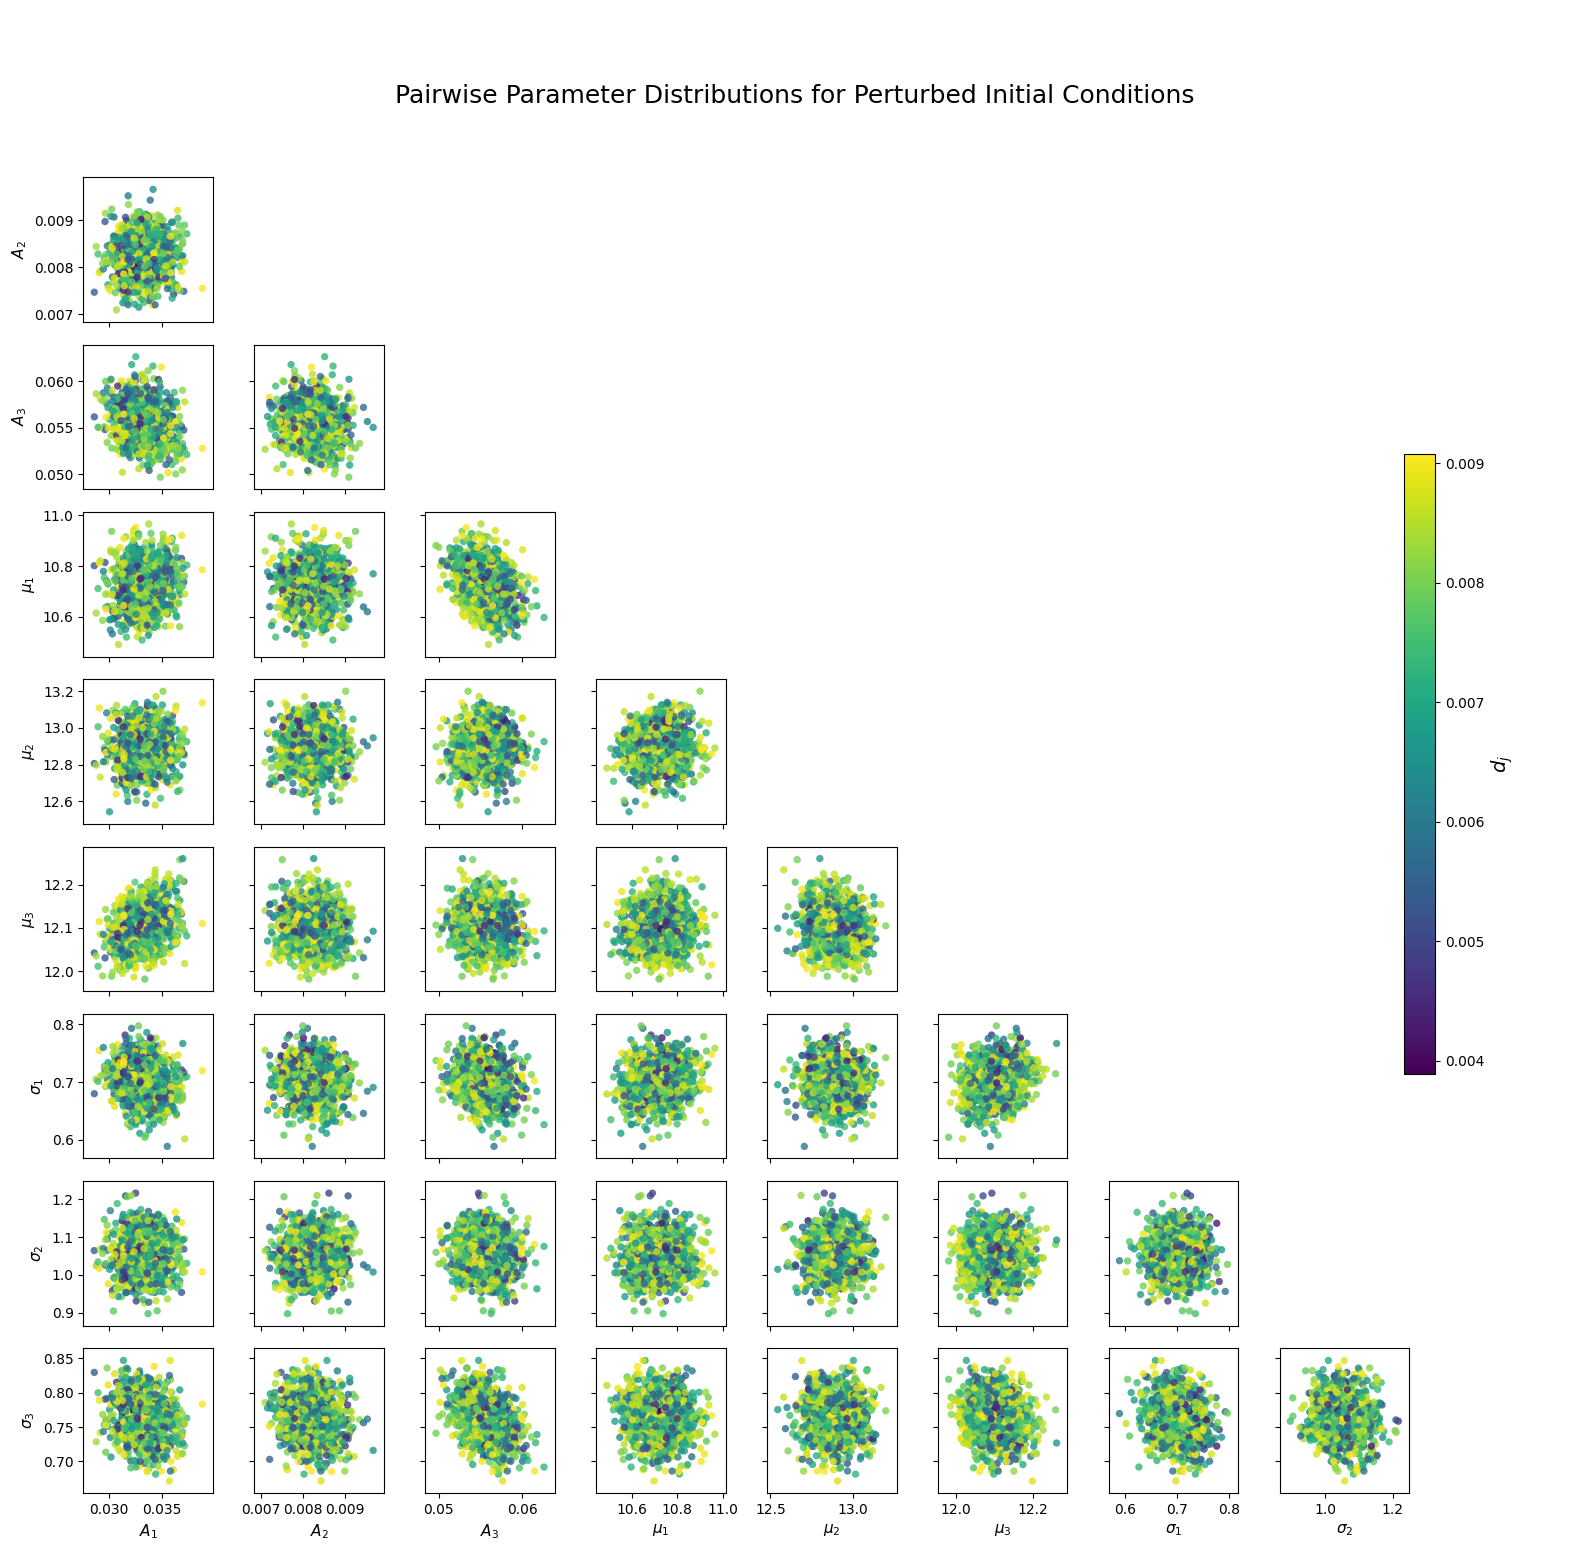

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# DATAFRAME
# ============================================================

columns = [
    r'$A_1$',
    r'$A_2$',
    r'$A_3$',
    r'$\mu_1$',
    r'$\mu_2$',
    r'$\mu_3$',
    r'$\sigma_1$',
    r'$\sigma_2$',
    r'$\sigma_3$'
]

df = pd.DataFrame(
    accepted_parameters,
    columns=columns
)

# ------------------------------------------------------------
# Add distances
# ------------------------------------------------------------

df[r'$d_j$'] = accepted_distances

# ============================================================
# COLORMAP NORMALIZATION
# ============================================================

norm = Normalize(
    vmin=df[r'$d_j$'].min(),
    vmax=df[r'$d_j$'].max()
)

cmap = plt.cm.viridis

# ============================================================
# CREATE FIGURE
# ============================================================

n = len(columns)

fig, axes = plt.subplots(
    n,
    n,
    figsize=(16, 16)
)

# ============================================================
# LOWER TRIANGLE SCATTER PLOTS
# ============================================================

for i in range(n):

    for j in range(n):

        ax = axes[i, j]

        # ----------------------------------------------------
        # Remove upper triangle
        # ----------------------------------------------------

        if j > i:
            ax.axis('off')
            continue

        # ----------------------------------------------------
        # Remove diagonal
        # ----------------------------------------------------

        if i == j:
            ax.axis('off')
            continue

        # ----------------------------------------------------
        # Scatter plot
        # ----------------------------------------------------

        x = df[columns[j]]
        y = df[columns[i]]

        scatter = ax.scatter(
            x,
            y,
            c=df[r'$d_j$'],
            cmap=cmap,
            norm=norm,
            s=28,
            alpha=0.8,
            linewidths=0
        )

        # ----------------------------------------------------
        # Margins
        # ----------------------------------------------------

        x_margin = 0.10 * (x.max() - x.min())
        y_margin = 0.10 * (y.max() - y.min())

        ax.set_xlim(
            x.min() - x_margin,
            x.max() + x_margin
        )

        ax.set_ylim(
            y.min() - y_margin,
            y.max() + y_margin
        )

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        if i == n - 1:
            ax.set_xlabel(columns[j], fontsize=11)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(columns[i], fontsize=11)
        else:
            ax.set_yticklabels([])

# ============================================================
# COLORBAR
# ============================================================

sm = ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.025,
    pad=0.02
)

cbar.set_label(r'$d_j$', fontsize=14)

# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    'Pairwise Parameter Distributions for Perturbed Initial Conditions',
    fontsize=18,
    y=0.92
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

plt.show()

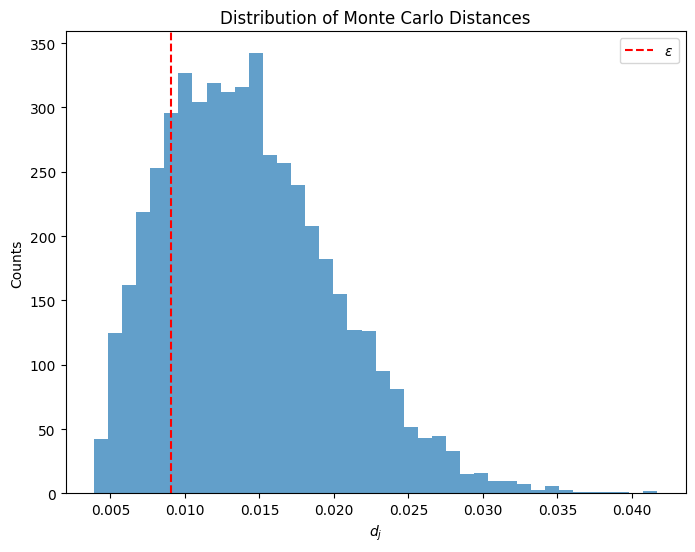

In [16]:
# ============================================================
# HISTOGRAM OF DISTANCES
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    all_distances,
    bins=40,
    alpha=0.7
)

plt.axvline(
    epsilon,
    color='red',
    linestyle='--',
    label=r'$\epsilon$'
)

plt.xlabel(r'$d_j$')
plt.ylabel('Counts')

plt.title(
    'Distribution of Monte Carlo Distances'
)

plt.legend()

plt.show()

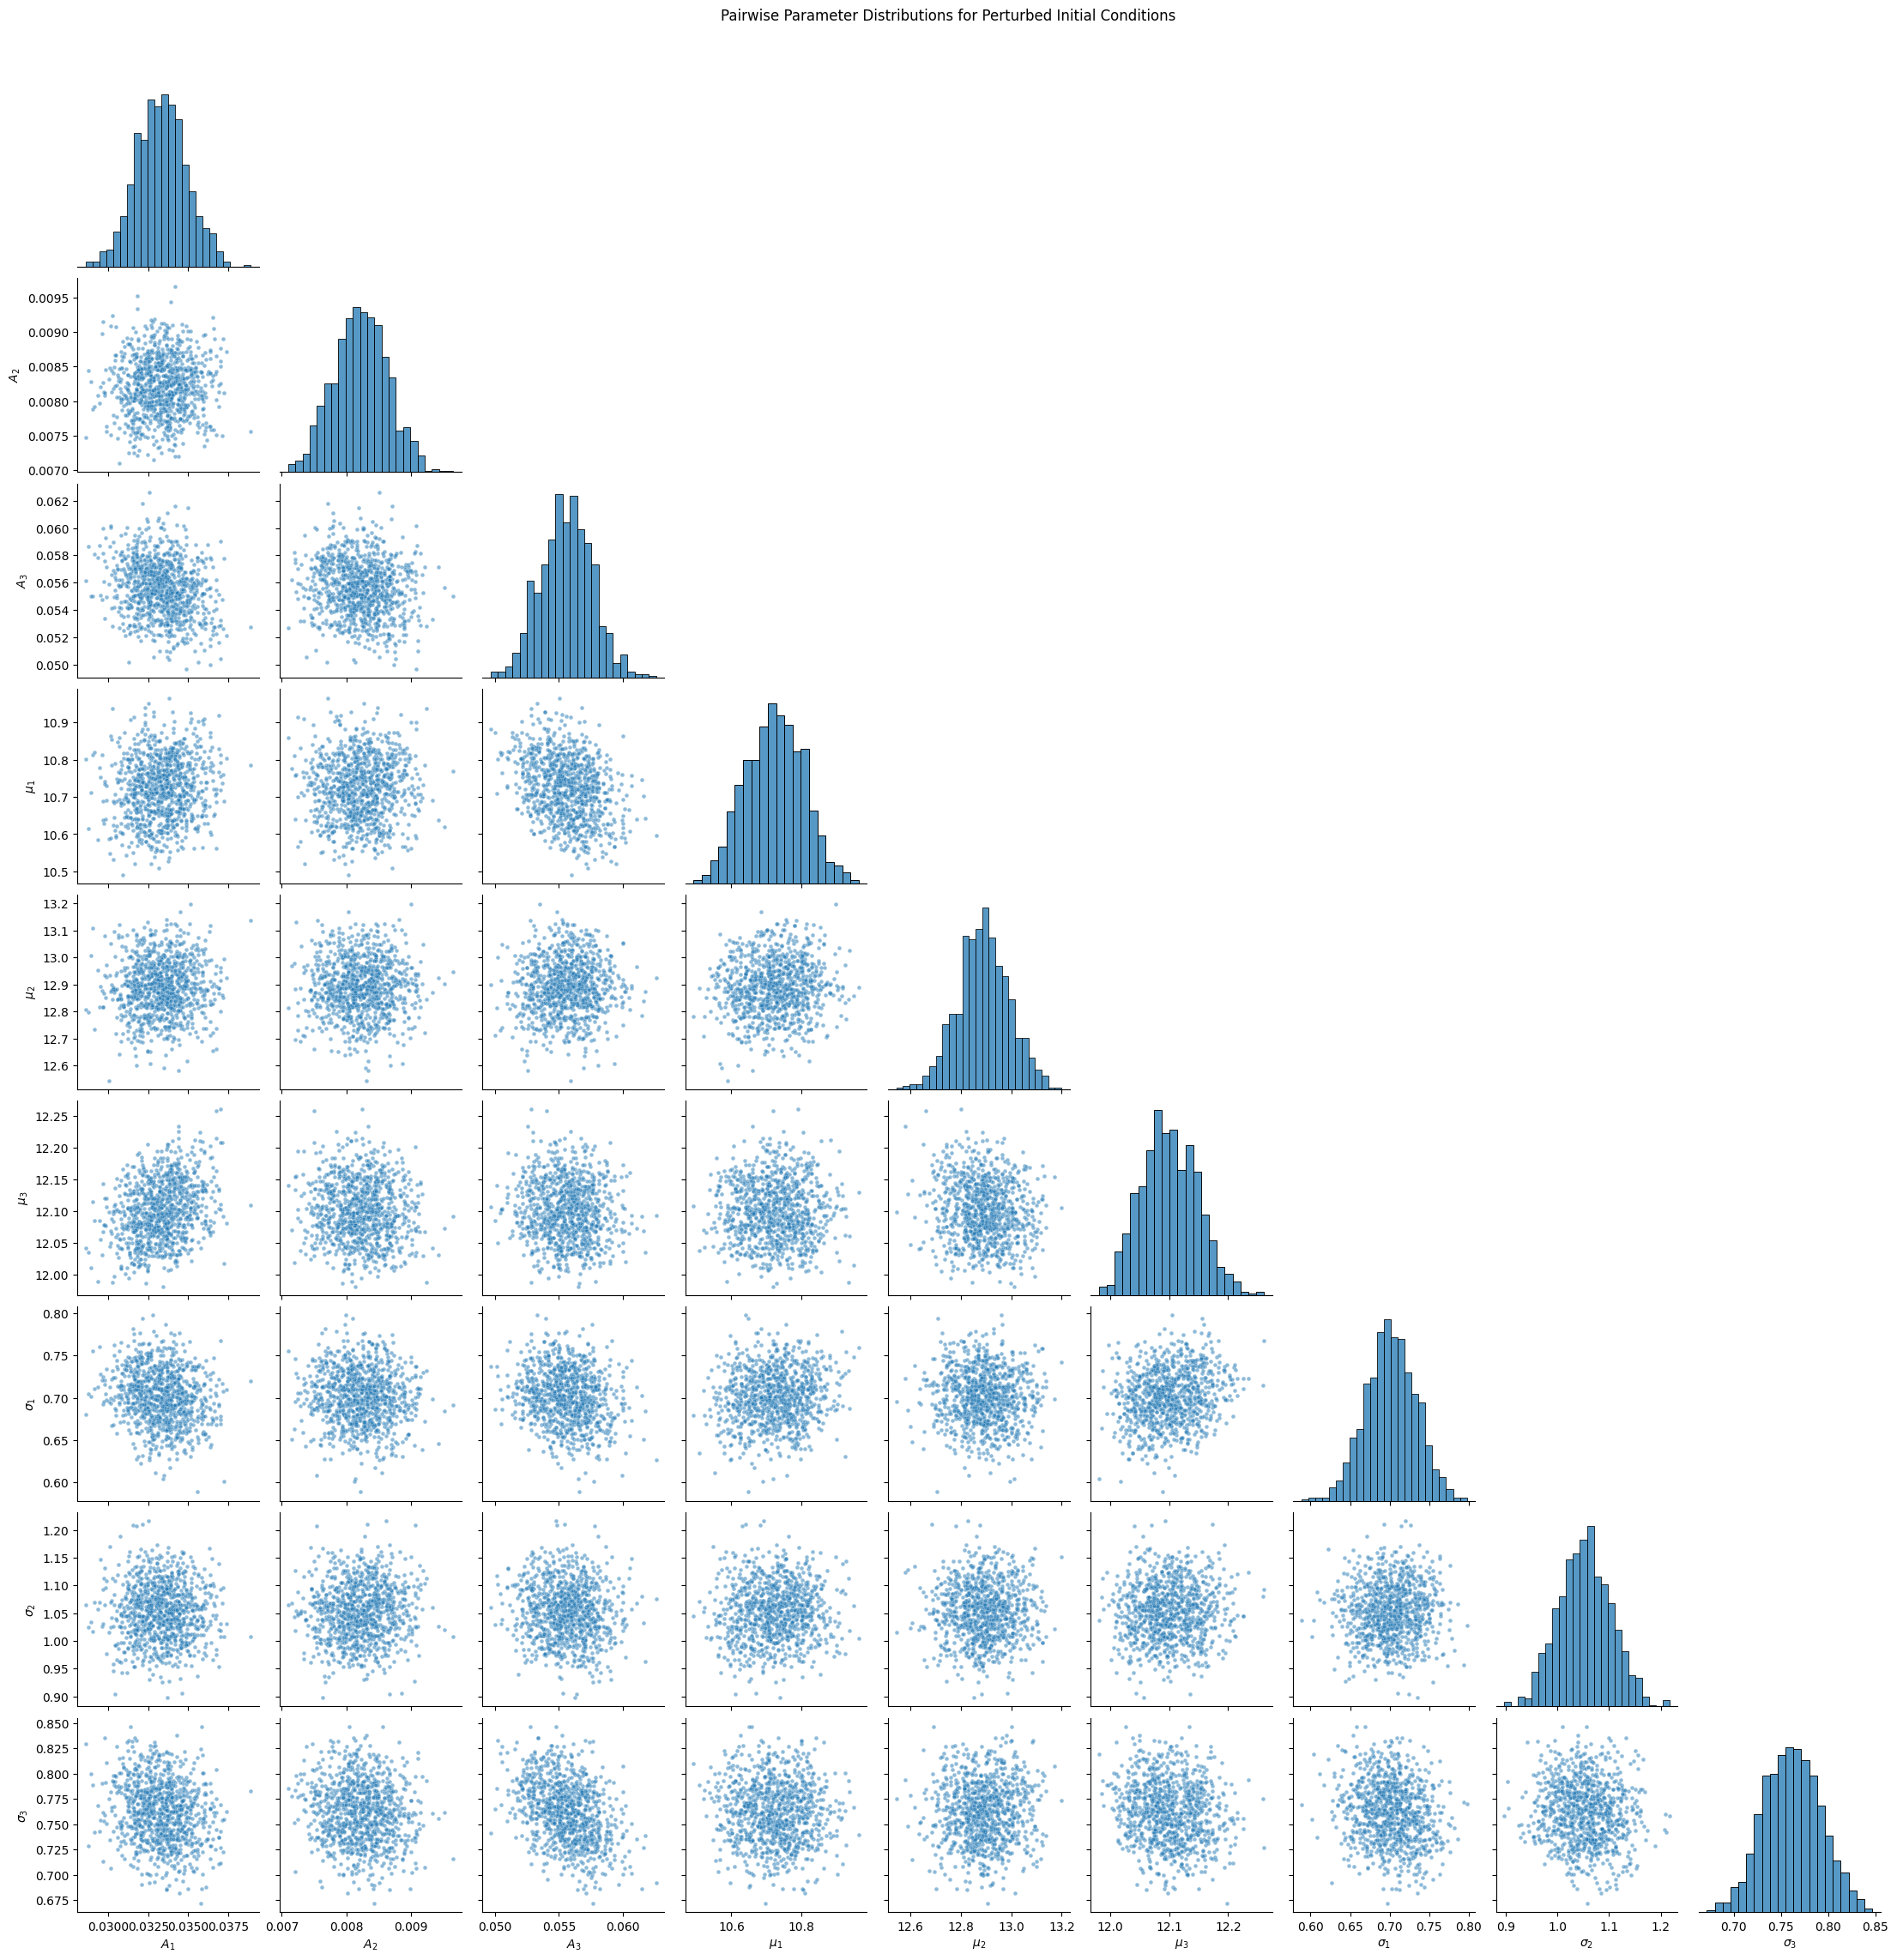

In [17]:
# ============================================================
# PAIRWISE PARAMETER DISTRIBUTIONS
# ============================================================

columns = [
    r'$A_1$',
    r'$A_2$',
    r'$A_3$',
    r'$\mu_1$',
    r'$\mu_2$',
    r'$\mu_3$',
    r'$\sigma_1$',
    r'$\sigma_2$',
    r'$\sigma_3$'
]

df = pd.DataFrame(
    accepted_parameters,
    columns=columns
)

g = sns.pairplot(
    df,
    corner=True,
    diag_kind='hist',
    plot_kws={
        's': 12,
        'alpha': 0.5
    }
)

g.figure.suptitle(
    'Pairwise Parameter Distributions for Perturbed Initial Conditions',
    y=1.02
)

plt.show()

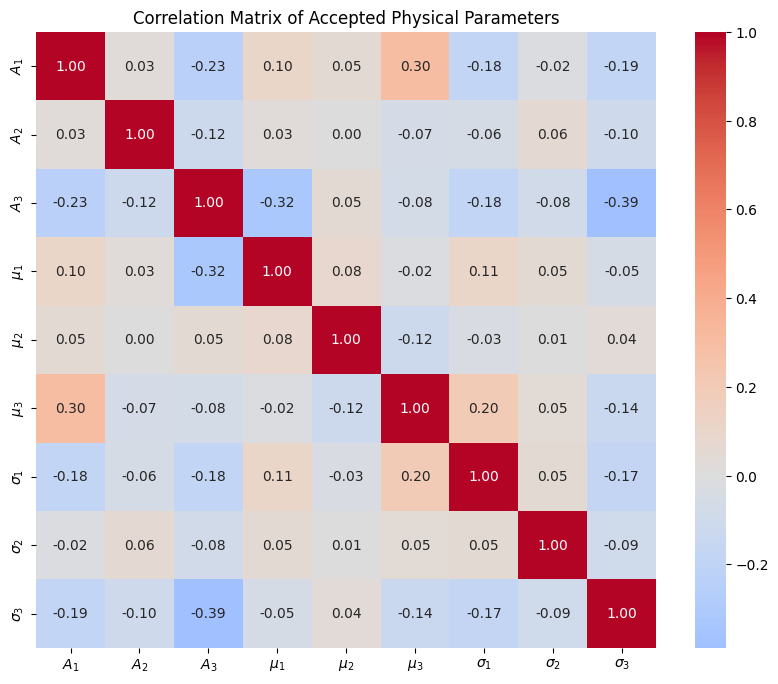

In [18]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

corr = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title(
    'Correlation Matrix of Accepted Physical Parameters'
)

plt.show()

In [19]:
# ------------------------------------------------------------
# Benchmark model parameters
# ------------------------------------------------------------

benchmark_model = {
    "mbh_par": 2.0,     # corresponds to 2e11
    "alpha": 0.3,
    "tau_star": 5.0,    # Gyr
    "eta0": 0.1,
    "t_q": 1.0,         # Gyr
    "b1": 0.1,
    "b2": 0.1
}

In [20]:
# ------------------------------------------------------------
# Containers
# ------------------------------------------------------------

accepted_model_params = []
all_model_distances = []
accepted_model_distances = []

In [21]:
# ============================================================
# MONTE CARLO LOOP
# ============================================================

for i in tqdm(range(N_MONTE_CARLO)):

    # --------------------------------------------------------
    # Perturb parameters
    # --------------------------------------------------------

    mbh_par = (
        benchmark_model["mbh_par"]
        * (1.0 + 0.10*np.random.randn())
    )

    alpha = (
        benchmark_model["alpha"]
        + 0.03*np.random.randn()
    )

    tau_star = (
        benchmark_model["tau_star"]
        * (1.0 + 0.20*np.random.randn())
    )

    eta0 = (
        benchmark_model["eta0"]
        + 0.03*np.random.randn()
    )

    t_q = (
        benchmark_model["t_q"]
        * (1.0 + 0.20*np.random.randn())
    )

    b1 = (
        benchmark_model["b1"]
        + 0.05*np.random.randn()
    )

    b2 = (
        benchmark_model["b2"]
        + 0.05*np.random.randn()
    )

    # --------------------------------------------------------
    # Enforce positivity
    # --------------------------------------------------------

    mbh_par = np.clip(mbh_par, 0.5, 10.0)
    alpha = np.clip(alpha, 0.01, 1.0)
    tau_star = np.clip(tau_star, 0.1, 20.0)

    eta0 = np.clip(eta0, 0.01, 0.5)
    t_q = np.clip(t_q, 0.1, 10.0)

    b1 = np.clip(b1, 0.0, 1.0)
    b2 = np.clip(b2, 0.0, 1.0)

    # --------------------------------------------------------
    # Build accretion model
    # --------------------------------------------------------

    accretion_params_mc = ParameterAccretionRate(

        mbh_par=mbh_par * 1e11,
        alpha_par=alpha,
        tau_par=tau_star * 1e9,

        eta=eta0,
        t_q=t_q * 1e9,
        b_1=b1,
        b_2=b2
    )

    # --------------------------------------------------------
    # Forward evolution
    # --------------------------------------------------------

    outputs_mc = ray.get(
        objective_function.directly_problem.remote(
            initial_condition,
            accretion_params_mc
        )
    )

    # --------------------------------------------------------
    # Distance to noisy target
    # --------------------------------------------------------

    d_j = np.linalg.norm(
        outputs_mc.n_final - target_data
    )

    all_model_distances.append(d_j)

    # --------------------------------------------------------
    # Accept degenerate realizations
    # --------------------------------------------------------

    if d_j <= epsilon:

        accepted_model_params.append([
            mbh_par,
            alpha,
            tau_star,
            t_q,
            b1,
            b2,
            eta0
        ])
        accepted_model_distances.append(d_j)

100%|██████████| 5000/5000 [04:57<00:00, 16.83it/s]


In [22]:
# ============================================================
# RESULTS
# ============================================================

accepted_model_params = np.array(accepted_model_params)

print(
    f"Accepted model realizations: "
    f"{len(accepted_model_params)}"
)

Accepted model realizations: 216


In [23]:
# ============================================================
# PAIRWISE MODEL DEGENERACY MAP
# ============================================================

columns_model = [
    r"$T'_0$",
    r"$\alpha$",
    r"$\tau_{*}$",
    r"$t_q$",
    r"$b_1$",
    r"$b_2$",
    r"$\bar{\eta}^{0}$"
]

df_model = pd.DataFrame(
    accepted_model_params,
    columns=columns_model
)

/tmp/ipykernel_91195/4125940501.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


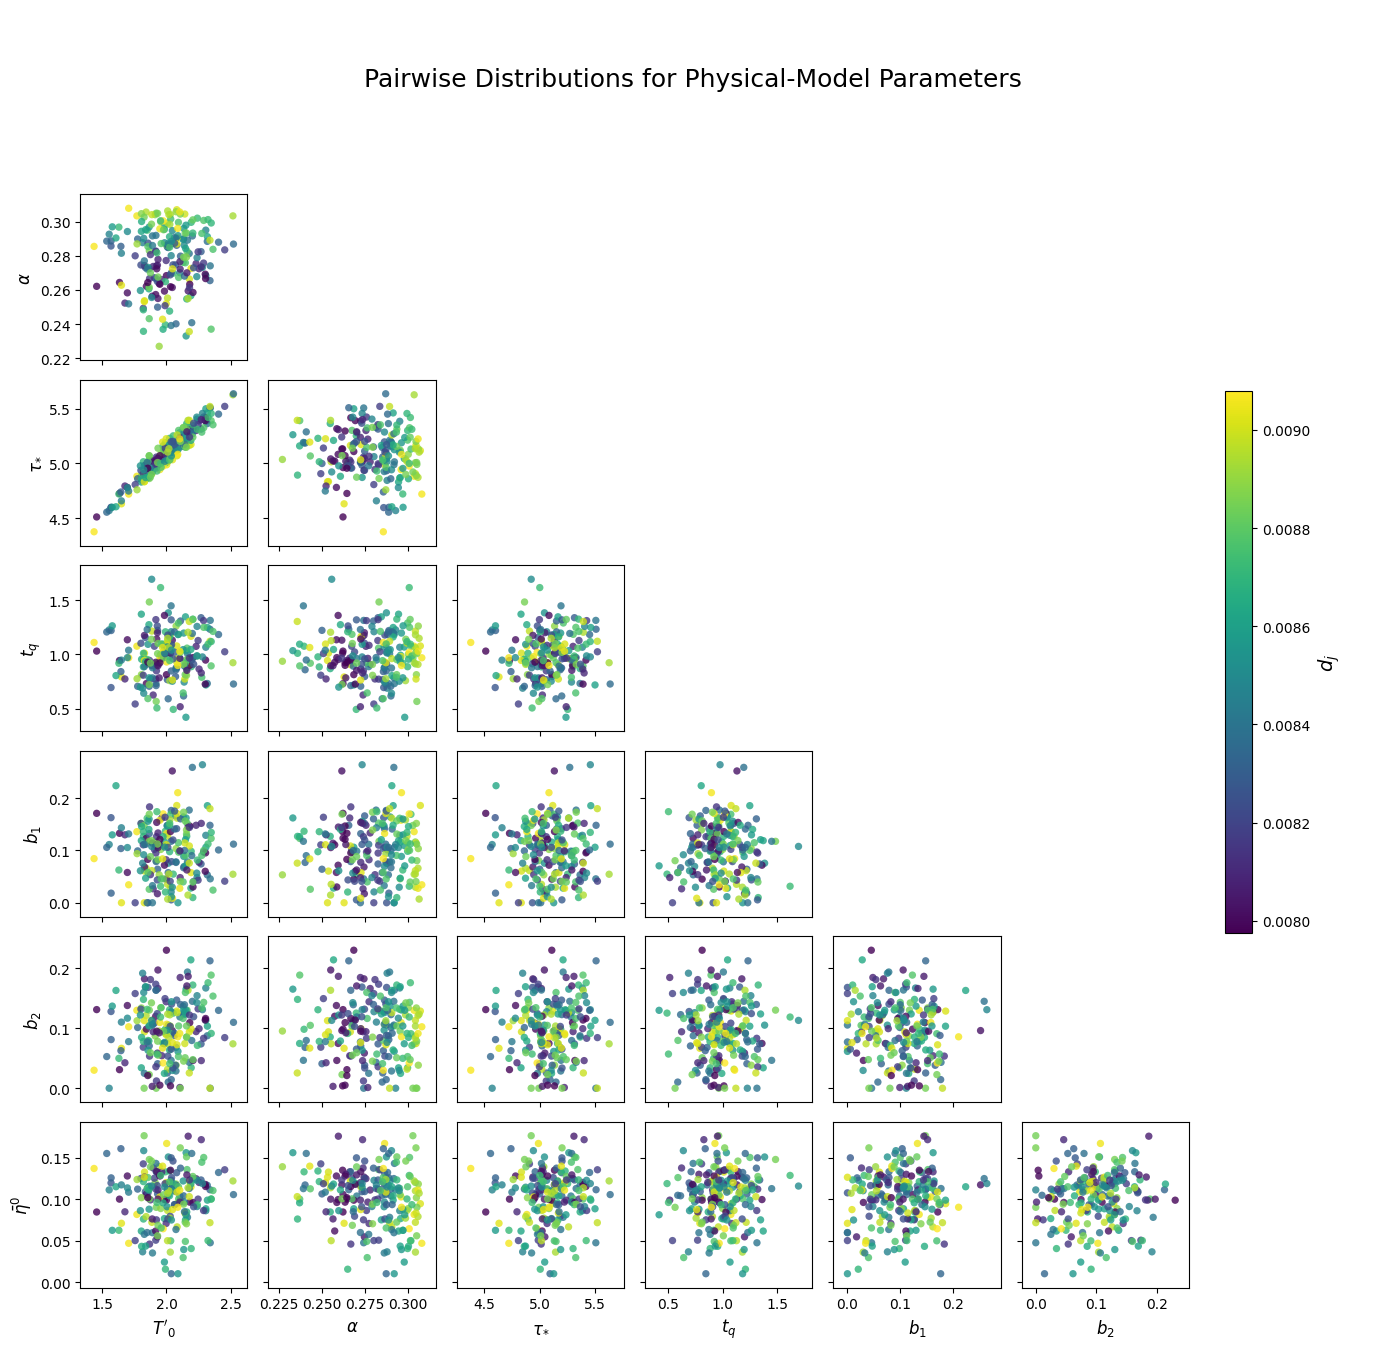

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# DATAFRAME
# ============================================================

columns_model = [
    r"$T'_0$",
    r"$\alpha$",
    r"$\tau_{*}$",
    r"$t_q$",
    r"$b_1$",
    r"$b_2$",
    r"$\bar{\eta}^{0}$"
]

df_model = pd.DataFrame(
    accepted_model_params,
    columns=columns_model
)

# ------------------------------------------------------------
# Add distances
# ------------------------------------------------------------

df_model[r'$d_j$'] = accepted_model_distances

# ============================================================
# COLORMAP NORMALIZATION
# ============================================================

norm = Normalize(
    vmin=df_model[r'$d_j$'].min(),
    vmax=df_model[r'$d_j$'].max()
)

cmap = plt.cm.viridis

# ============================================================
# CREATE FIGURE MANUALLY
# ============================================================

n = len(columns_model)

fig, axes = plt.subplots(
    n,
    n,
    figsize=(14, 14)
)

# ============================================================
# LOWER TRIANGLE SCATTER PLOTS
# ============================================================

for i in range(n):

    for j in range(n):

        ax = axes[i, j]

        # ----------------------------------------------------
        # Remove upper triangle
        # ----------------------------------------------------

        if j > i:
            ax.axis('off')
            continue

        # ----------------------------------------------------
        # Remove diagonal histograms
        # ----------------------------------------------------

        if i == j:
            ax.axis('off')
            continue

        # ----------------------------------------------------
        # Scatter plot
        # ----------------------------------------------------

        x = df_model[columns_model[j]]
        y = df_model[columns_model[i]]

        scatter = ax.scatter(
            x,
            y,
            c=df_model[r'$d_j$'],
            cmap=cmap,
            norm=norm,
            s=28,
            alpha=0.8,
            linewidths=0
        )

        # ----------------------------------------------------
        # Margins
        # ----------------------------------------------------

        x_margin = 0.10 * (x.max() - x.min())
        y_margin = 0.10 * (y.max() - y.min())

        ax.set_xlim(
            x.min() - x_margin,
            x.max() + x_margin
        )

        ax.set_ylim(
            y.min() - y_margin,
            y.max() + y_margin
        )

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        if i == n - 1:
            ax.set_xlabel(columns_model[j], fontsize=12)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(columns_model[i], fontsize=12)
        else:
            ax.set_yticklabels([])

# ============================================================
# COLORBAR
# ============================================================

sm = ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.025,
    pad=0.02
)

cbar.set_label(r'$d_j$', fontsize=14)

# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    'Pairwise Distributions for Physical-Model Parameters',
    fontsize=18,
    y=0.92
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

plt.show()

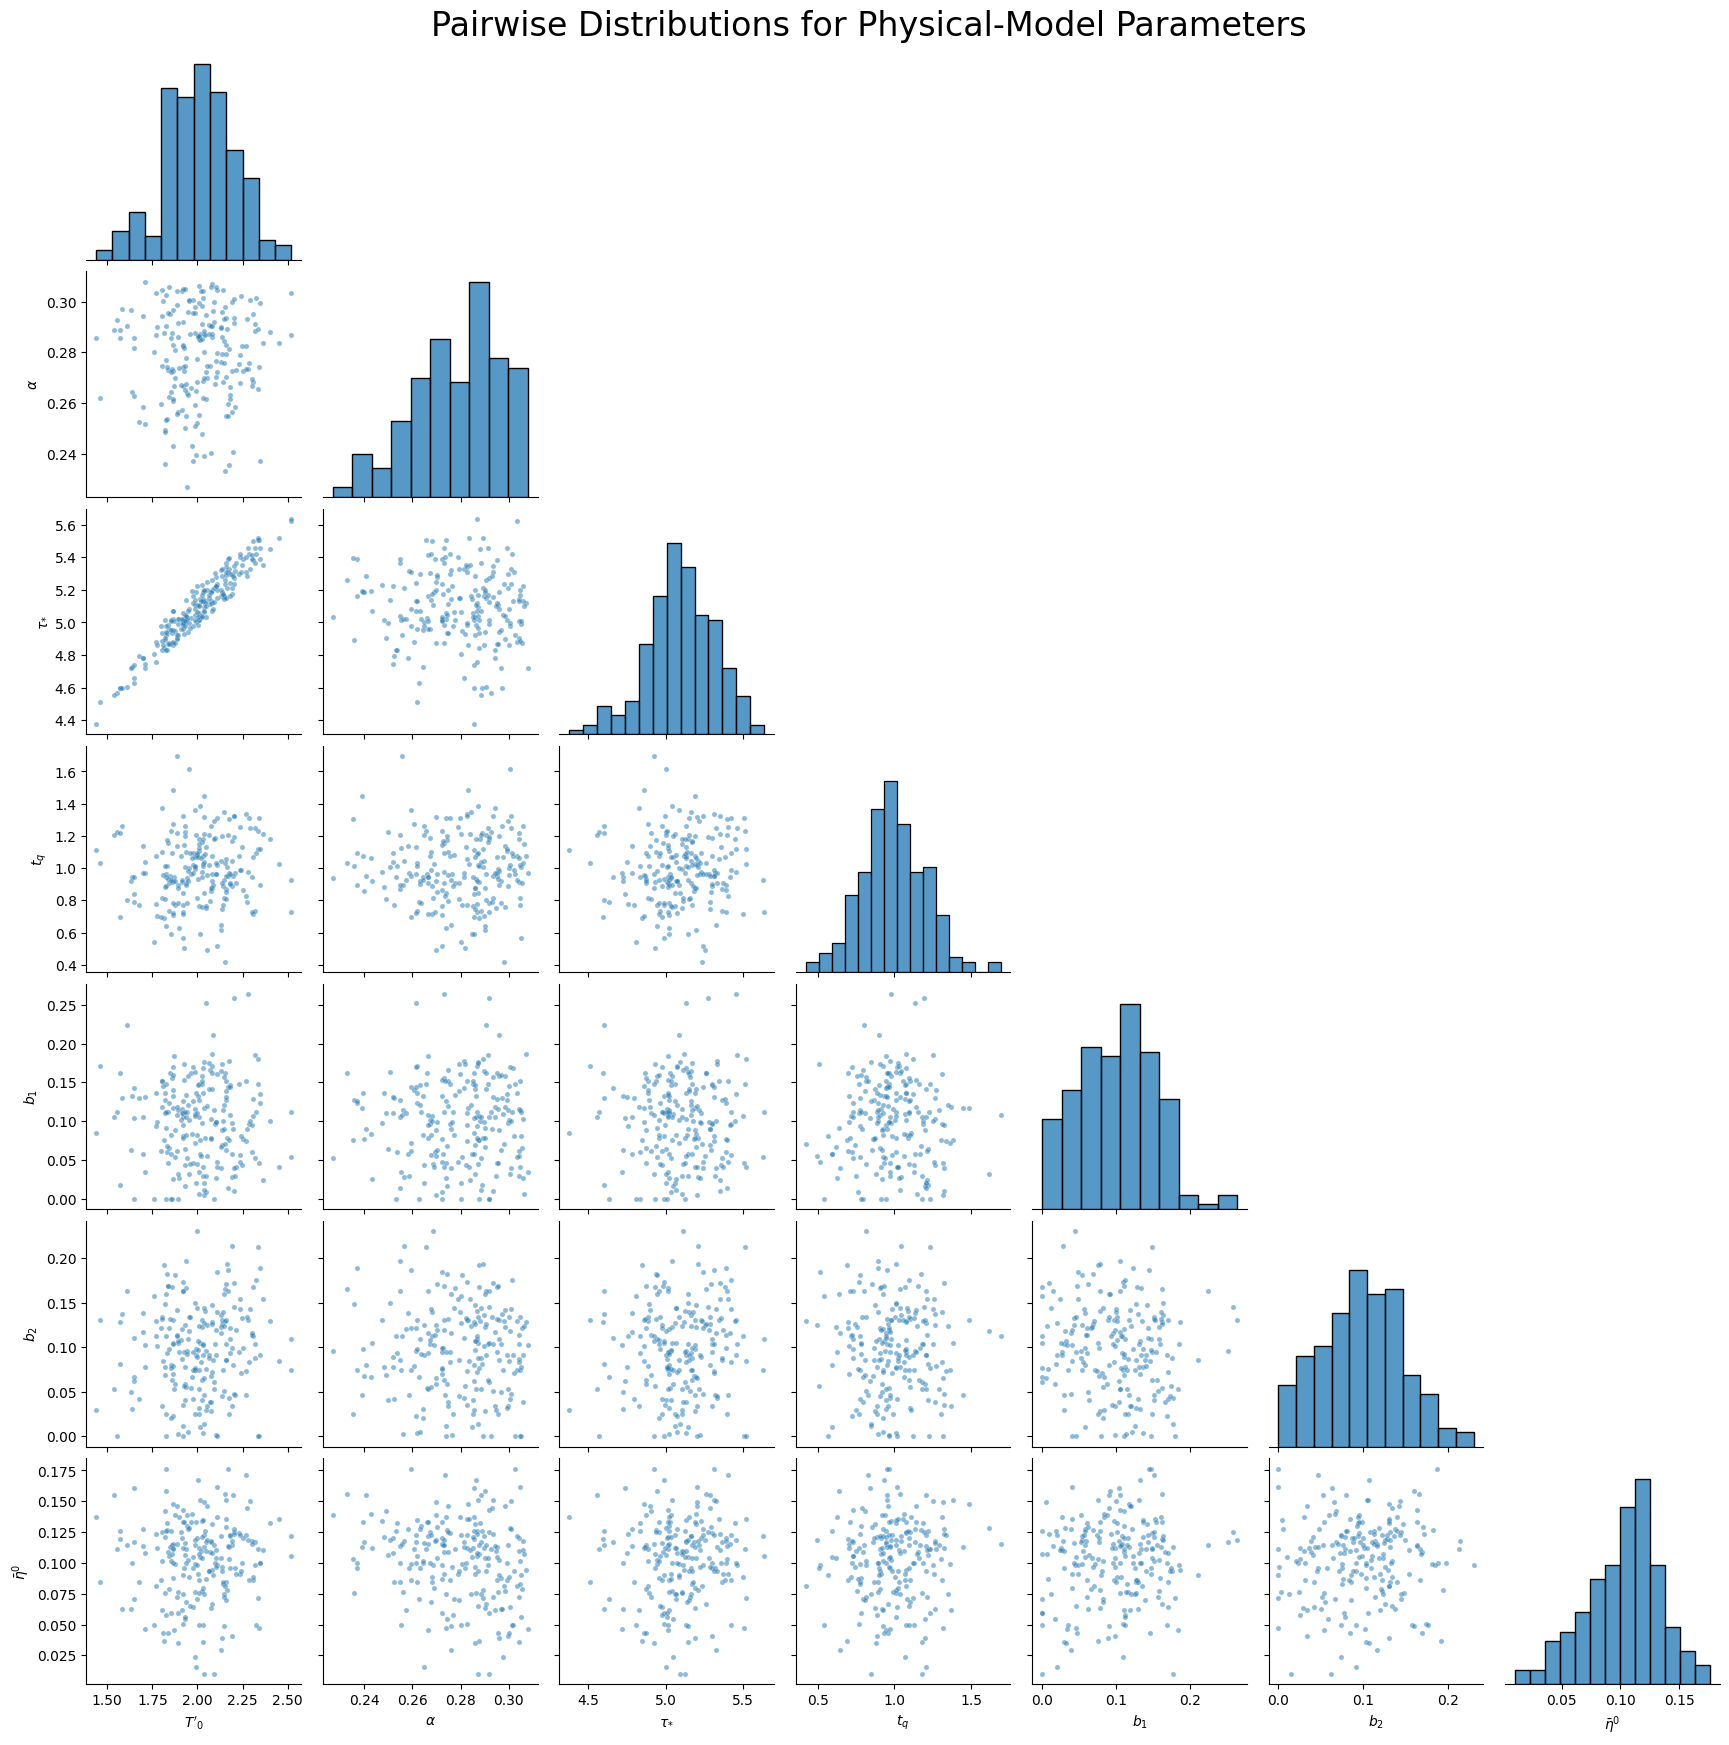

In [34]:
# ============================================================
# DATAFRAME
# ============================================================

columns_model = [
    r"$T'_0$",
    r"$\alpha$",
    r"$\tau_{*}$",
    r"$t_q$",
    r"$b_1$",
    r"$b_2$",
    r"$\bar{\eta}^{0}$"
]

df_model = pd.DataFrame(
    accepted_model_params,
    columns=columns_model
)

# ------------------------------------------------------------
# Pairplot
# ------------------------------------------------------------

g = sns.pairplot(
    df_model,
    corner=True,
    diag_kind='hist',
    plot_kws={
        's': 14,
        'alpha': 0.5
    }
)

g.figure.suptitle(
    'Pairwise Distributions for Physical-Model Parameters',
    fontsize=24,
    y=1.0
    
)

plt.show()

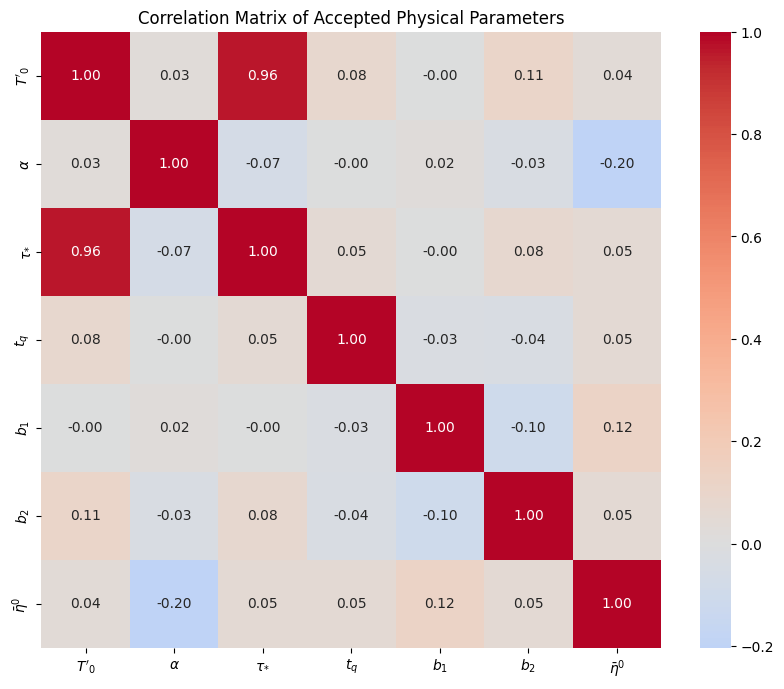

In [28]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

corr = df_model.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title(
    'Correlation Matrix of Accepted Physical Parameters'
)

plt.show()